In [74]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('../data/merged_final_transformed.csv')

# Display the first few rows to verify
print(df.shape)
df.head()

(6646, 41)


,year,StateAbbr,County name,CountyFIPS,BPHIGH,CASTHMA,COPD,MHLTH,PHLTH,SLEEP,...,median_age,pct_bachelors_plus,pct_graduate_degree,pct_less_than_hs,pct_white,pct_black,pct_asian,pct_hispanic,median_household_income,climate_type_short
0,2013,AK,ANCHORAGE MUNICIPALITY,2020,28.691667,NaN,NaN,NaN,NaN,NaN,...,32.8,11.7,92.5,23.2,0.1,7.9,7.8,92.0,77454,ET
1,2013,AL,JEFFERSON COUNTY,1073,41.893750,NaN,NaN,NaN,NaN,NaN,...,37.2,11.6,87.4,26.6,0.1,0.8,0.8,96.2,45429,Cfa
2,2013,AL,MADISON COUNTY,1089,37.654348,NaN,NaN,NaN,NaN,NaN,...,37.4,14.5,90.0,21.4,0.1,2.3,2.2,95.4,58434,Cfa
3,2013,AL,MOBILE COUNTY,1097,44.833333,NaN,NaN,NaN,NaN,NaN,...,36.7,7.0,83.9,33.0,0.0,1.4,1.4,97.5,43028,Cfa
4,2013,AL,MONTGOMERY COUNTY,1101,39.792727,NaN,NaN,NaN,NaN,NaN,...,34.8,12.0,85.6,26.2,0.1,1.3,1.1,96.5,44790,Cfa


# Pivoting the data

In [75]:
# no longer needed so commented out

# measure_specific = ['measureid_c', 'measure_c', 'data_value_c', 'low_confidence_limit_c',
#                    'high_confidence_limit_c', 'category_c', 'categoryid_c', 'short_question_text_c']
# index_cols = [c for c in df.columns if c not in measure_specific]

# df_pivot = df.pivot(
#    index=index_cols,
#    columns='measureid_c',
#    values='data_value_c'
#).reset_index()

# df_pivot.columns.name = None

# print(df_pivot.shape)
# df_pivot.head()

# df_pivot.to_csv('../data/df_pivot.csv', index=False)


# Exploratory Analysis

In [76]:
#Year-wise country-wise data

df.groupby(['year', 'StateAbbr']).size().unstack(fill_value=0)

StateAbbr,AK,AL,AR,AZ,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
year,,,,,,,,,,,,,,,,,,,,,
2013,1,6,5,4,25,7,3,1,14,8,...,2,4,29,2,3,1,7,6,1,1
2014,1,6,5,4,25,7,3,1,14,8,...,2,4,29,2,3,1,7,6,1,1
2015,1,6,5,4,25,7,3,1,14,8,...,2,4,29,2,3,1,7,6,1,1
2016,1,6,5,4,25,7,3,1,14,8,...,2,4,29,2,3,1,7,6,1,1
2017,1,6,5,4,25,7,3,1,14,8,...,2,4,29,2,3,1,7,6,1,1
2018,23,27,21,12,40,25,5,2,29,20,...,21,11,82,9,16,8,22,23,11,19
2019,24,27,21,12,40,25,5,2,29,20,...,21,11,82,9,16,8,22,23,11,19
2020,24,27,21,12,40,25,5,2,29,20,...,21,11,82,9,16,8,22,23,11,19
2021,24,27,21,12,40,25,5,2,29,20,...,21,11,82,9,16,8,22,23,11,19


In [77]:
#Missing Values
missing = df.isnull().mean().mul(100).round(2).sort_values(ascending=False)
print(missing[missing > 0])  # only show columns that actually have missing values


SLEEP           51.93
BPHIGH           9.25
PRCP             8.50
HTDD             8.05
CLDD             7.84
TAVG             7.70
DT32             7.39
TMIN             7.39
EMNT             7.39
TMAX             7.28
EMXT             7.28
DX70             7.28
DX32             7.28
DX90             7.28
MHLTH            4.88
STROKE           4.88
CASTHMA          4.88
COPD             4.88
PHLTH            4.88
ELEVATION        0.68
LONGITUDE        0.68
STATION          0.68
STATION_NAME     0.68
LATITUDE         0.68
dtype: float64


In [78]:
missing = pd.DataFrame({
    'total': df.shape[0],
    'missing': df.isnull().sum(),
    'pct_missing': df.isnull().mean().mul(100).round(2)
})
missing[missing['missing'] > 0].sort_values('pct_missing', ascending=False)


,total,missing,pct_missing
SLEEP,6646,3451,51.93
BPHIGH,6646,615,9.25
PRCP,6646,565,8.50
HTDD,6646,535,8.05
CLDD,6646,521,7.84
TAVG,6646,512,7.70
TMIN,6646,491,7.39
DT32,6646,491,7.39
EMNT,6646,491,7.39
TMAX,6646,484,7.28


## State-wise split (2014)

StateAbbr
CA    21.47
TX    12.02
FL     8.12
IL     5.68
NY     4.49
MA     3.72
AZ     3.30
WA     3.03
MI     2.86
OH     2.67
NC     2.51
PA     2.35
CO     1.80
GA     1.67
CT     1.66
NV     1.50
OR     1.45
WI     1.38
IN     1.33
TN     1.30
AL     1.26
MO     1.23
LA     1.18
NJ     1.05
OK     0.94
MN     0.94
KS     0.83
UT     0.80
SC     0.78
IA     0.74
NM     0.72
AR     0.65
KY     0.65
HI     0.60
VA     0.54
NE     0.51
DE     0.34
MS     0.27
ID     0.25
NH     0.25
AK     0.18
ME     0.17
SD     0.17
MT     0.16
WV     0.12
RI     0.10
VT     0.10
ND     0.10
WY     0.06
Name: total_population, dtype: float64


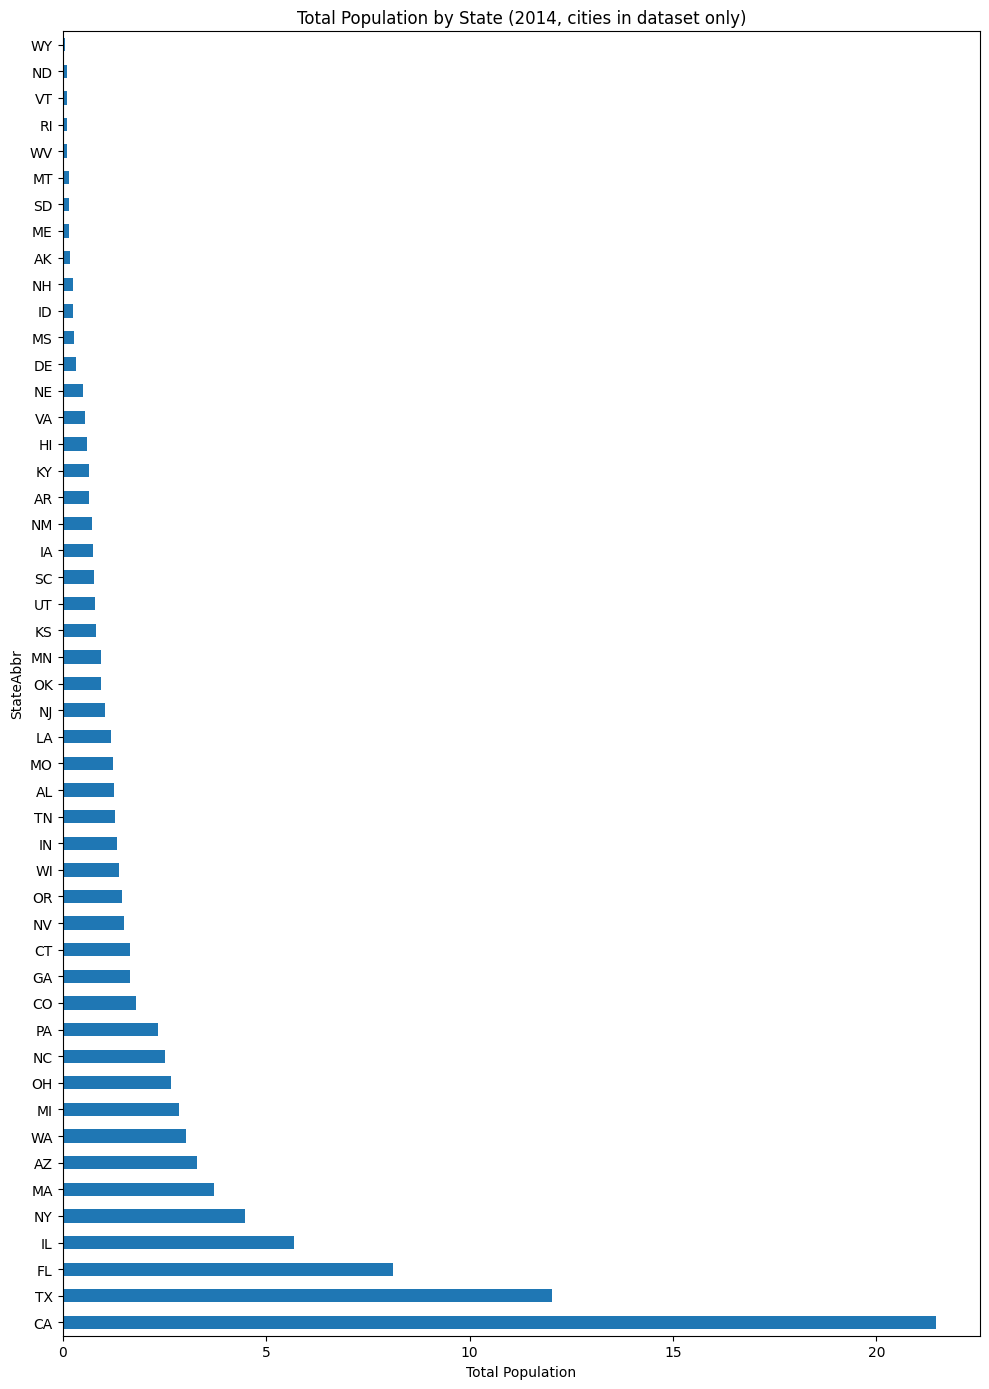

In [79]:
# Filter for 2014 only
df_2014 = df[df['year'] == 2014].copy()

# Sum population by state
state_pop_2014 = df_2014.groupby('StateAbbr')['total_population'].sum().sort_values(ascending=False)

state_pop_pct = (state_pop_2014 / state_pop_2014.sum() * 100).round(2)
print(state_pop_pct)

# Plot
import matplotlib.pyplot as plt

state_pop_pct.plot(
    kind='barh',
    figsize=(10, 14),
    title='Total Population by State (2014, cities in dataset only)'
)
plt.xlabel('Total Population')
plt.tight_layout()
plt.show()


   StateAbbr  count   pct
42        TX    637  9.58
4         CA    365  5.49
8         FL    244  3.67
21        MI    204  3.07
1         AL    192  2.89
33        NY    191  2.87
5         CO    185  2.78
23        MO    178  2.68
26        NC    176  2.65
13        IL    175  2.63
47        WI    168  2.53
46        WA    167  2.51
34        OH    167  2.51
28        NE    166  2.50
9         GA    160  2.41
15        KS    158  2.38
37        PA    157  2.36
2         AR    151  2.27
0         AK    148  2.23
36        OR    144  2.17
11        IA    138  2.08
40        SD    136  2.05
31        NM    134  2.02
25        MT    124  1.87
22        MN    123  1.85
49        WY    119  1.79
18        MA    118  1.78
35        OK    116  1.75
12        ID    113  1.70
44        VA    111  1.67
17        LA    108  1.63
14        IN    107  1.61
39        SC    104  1.56
3         AZ     92  1.38
41        TN     86  1.29
24        MS     82  1.23
27        ND     77  1.16
16        KY

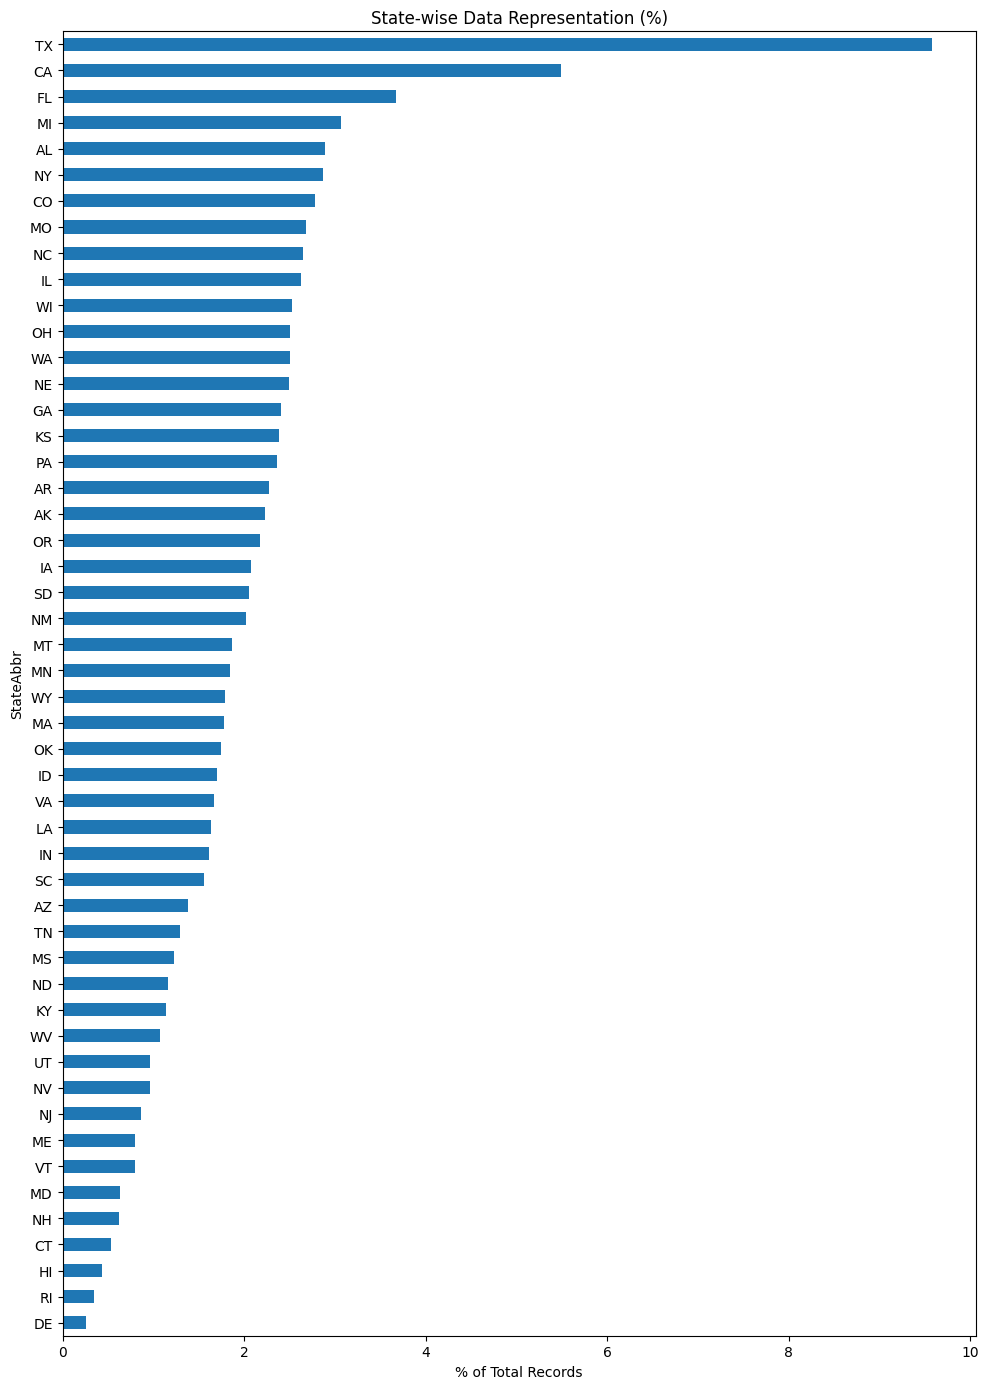

In [80]:
#Records per state
state_counts = df.groupby('StateAbbr').size().reset_index(name='count')
state_counts['pct'] = (state_counts['count'] / state_counts['count'].sum() * 100).round(2)
state_counts = state_counts.sort_values('pct', ascending=False)
print(state_counts)


#Visualise
import matplotlib.pyplot as plt

state_counts.set_index('StateAbbr')['pct'].sort_values().plot(
    kind='barh',
    figsize=(10, 14),
    title='State-wise Data Representation (%)'
)

plt.xlabel('% of Total Records')
plt.tight_layout()
plt.show()



## Gender

           pct_male  pct_female
StateAbbr                      
SC            48.30       51.70
AL            48.34       51.66
MS            48.34       51.66
GA            48.38       51.62
DE            48.47       51.53
LA            48.48       51.52
TN            48.59       51.41
RI            48.72       51.28
CT            48.81       51.19
MA            48.83       51.17
NC            48.93       51.07
KY            48.98       51.02
MO            49.07       50.93
NJ            49.11       50.89
AR            49.14       50.86
IN            49.25       50.75
ME            49.29       50.71
OH            49.32       50.68
PA            49.32       50.68
FL            49.36       50.64
IL            49.37       50.63
MD            49.43       50.57
NY            49.44       50.56
WV            49.53       50.47
VT            49.56       50.44
VA            49.70       50.30
NE            49.84       50.16
IA            49.85       50.15
NH            49.95       50.05
NM      

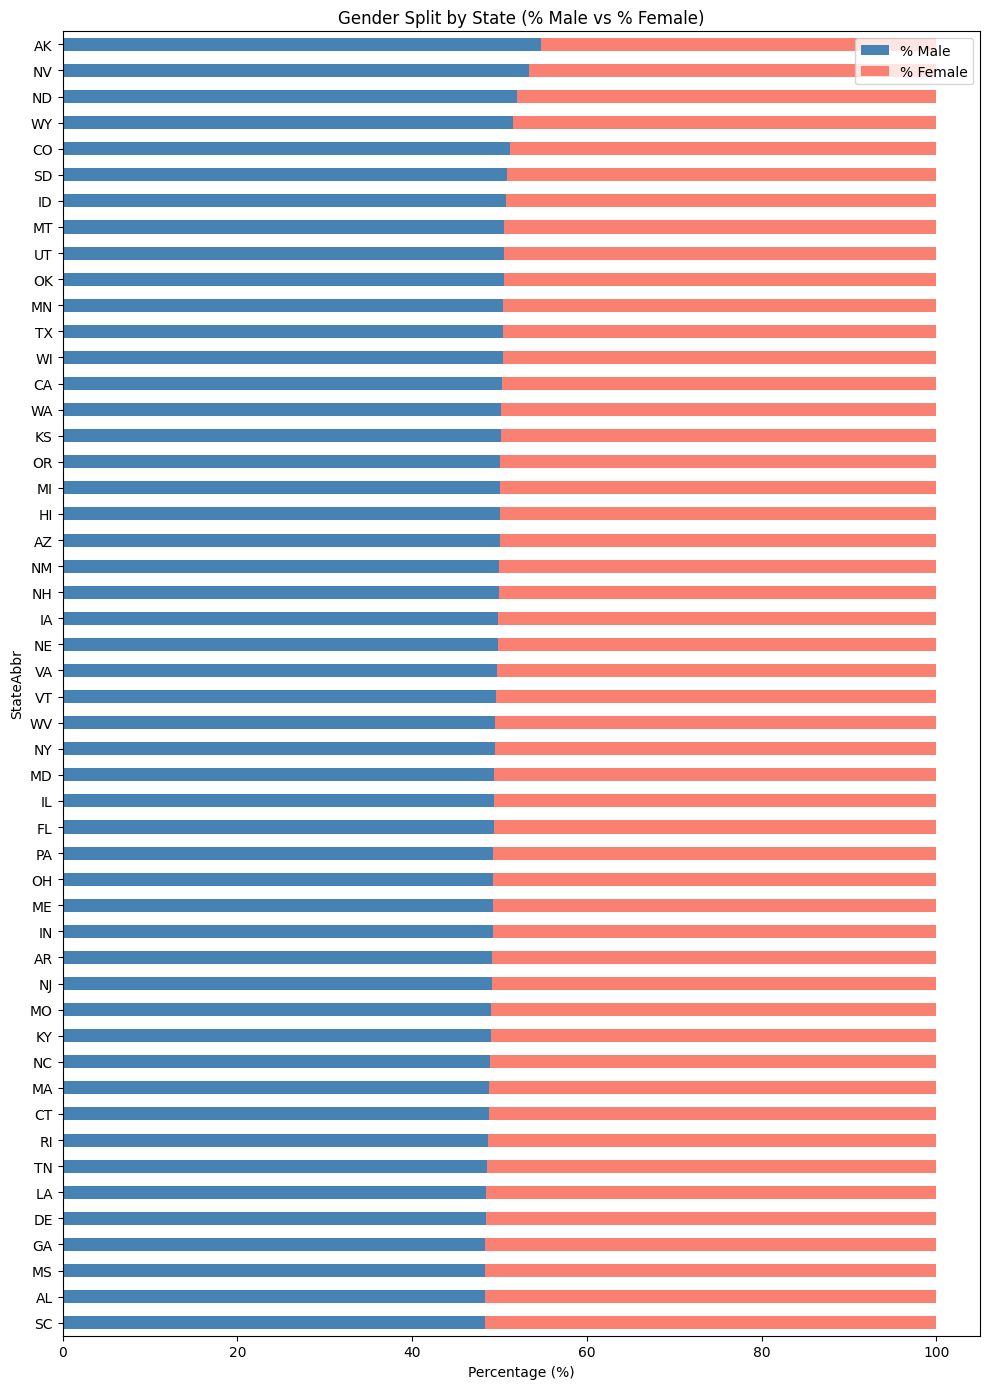

In [81]:
gender_by_state = df.groupby('StateAbbr')[['pct_male', 'pct_female']].mean().round(2)
gender_by_state = gender_by_state.sort_values('pct_female', ascending=False)
print(gender_by_state)

import matplotlib.pyplot as plt

gender_by_state.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 14),
    color=['steelblue', 'salmon'],
    title='Gender Split by State (% Male vs % Female)'
)

plt.xlabel('Percentage (%)')
plt.legend(['% Male', '% Female'])
plt.tight_layout()
plt.show()

# Univariate Analysis

## SLEEP - central tendency and spread 

In [82]:
#SLEEP country-wise

sleep_by_state = df.groupby('StateAbbr')['SLEEP'].agg(
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).round(2)

sleep_by_state['IQR'] = sleep_by_state['q3'] - sleep_by_state['q1']

sleep_by_state.sort_values('mean', ascending=True)


,mean,median,std,min,max,q1,q3,IQR
StateAbbr,,,,,,,,
SD,29.55,29.60,1.82,24.90,35.50,28.40,30.55,2.15
CO,29.68,29.50,3.14,21.49,37.20,27.55,31.95,4.40
MN,29.72,29.80,1.93,25.30,34.20,28.26,31.06,2.80
VT,30.35,30.75,3.04,24.45,35.35,28.12,32.10,3.98
NE,30.48,30.28,2.03,26.40,36.75,29.16,31.74,2.58
ND,31.26,31.20,2.16,27.10,39.35,30.09,32.24,2.15
WA,31.28,31.38,3.18,18.92,39.65,29.42,33.22,3.80
OR,31.43,31.50,2.77,25.20,36.85,29.66,33.55,3.89
IA,31.45,31.65,3.20,14.38,37.75,30.37,33.02,2.65


## SLEEP over years

['HI', 'WV', 'AL', 'NJ', 'LA']


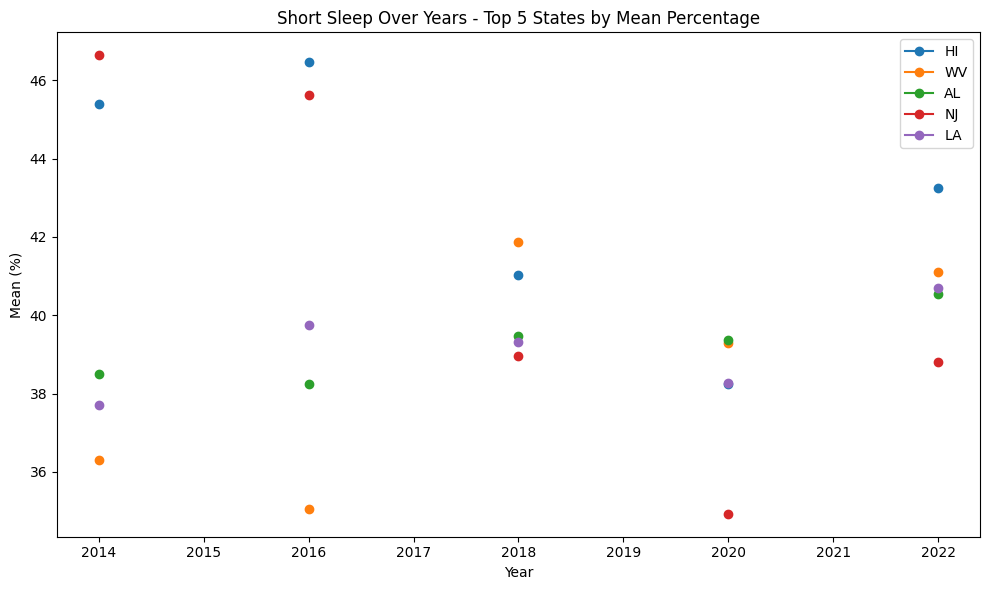

In [83]:
# Step 1: Get the top 5 states by mean Sleep
top5_states = sleep_by_state.sort_values('mean', ascending=False).head(5).index.tolist()
print(top5_states)

#Over-years
top5_df = df[df['StateAbbr'].isin(top5_states)]

top5_yearly = top5_df.groupby(['year', 'StateAbbr'])['SLEEP'].mean().reset_index()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for state in top5_states:
    state_data = top5_yearly[top5_yearly['StateAbbr'] == state]
    ax.plot(state_data['year'], state_data['SLEEP'], marker='o', label=state)

ax.set_title('Short Sleep Over Years - Top 5 States by Mean Percentage')
ax.set_xlabel('Year')
ax.set_ylabel('Mean (%)')
ax.legend()
plt.tight_layout()
plt.show()


## Outliers (State-wise)

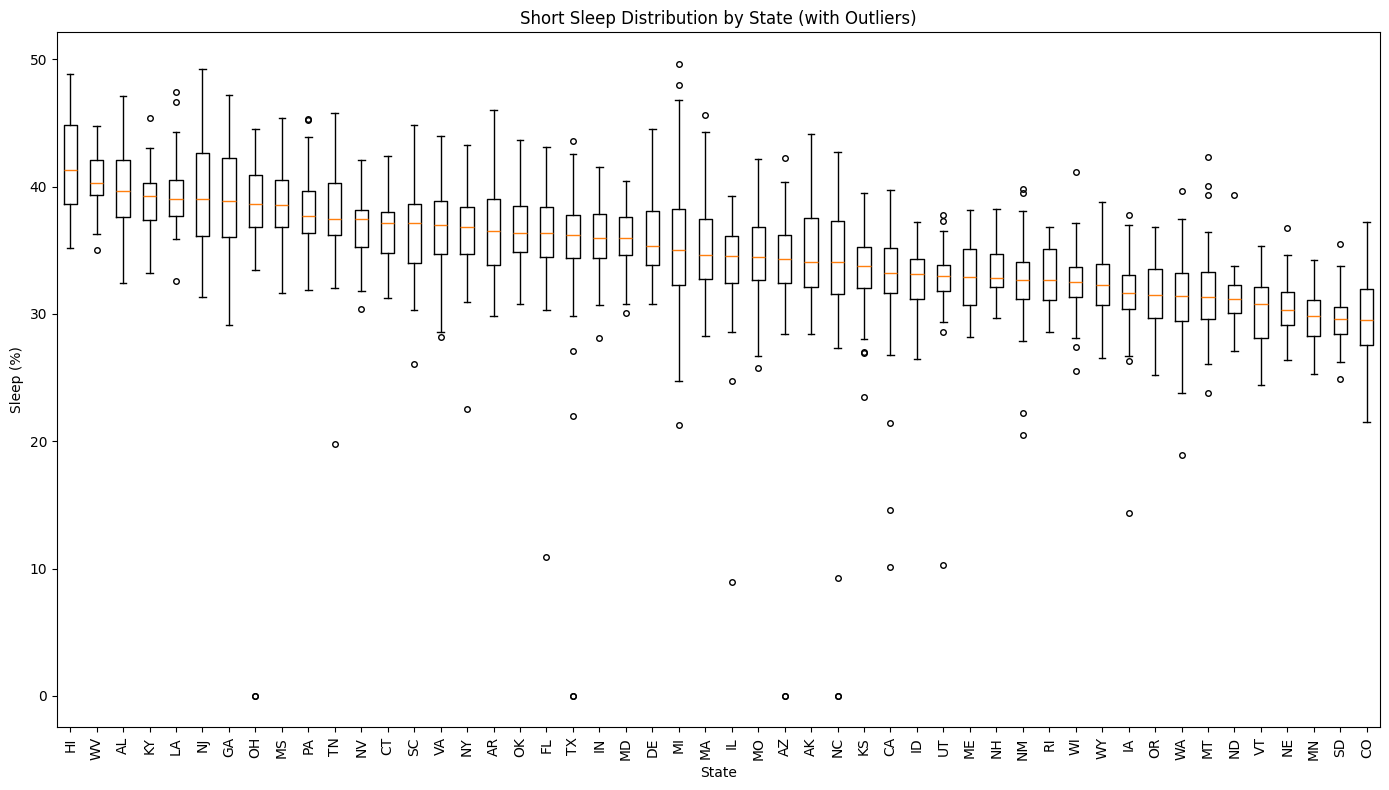

In [84]:
import matplotlib.pyplot as plt

sleep_data = df[['StateAbbr', 'SLEEP']].dropna()

states_ordered = sleep_data.groupby('StateAbbr')['SLEEP'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))

chd_data_sorted = [sleep_data[sleep_data['StateAbbr'] == state]['SLEEP'].values for state in states_ordered]

ax.boxplot(chd_data_sorted, flierprops=dict(marker='o', color='red', markersize=4))

ax.set_xticks(range(1, len(states_ordered) + 1))
ax.set_xticklabels(states_ordered, rotation=90)
ax.set_title('Short Sleep Distribution by State (with Outliers)')
ax.set_xlabel('State')
ax.set_ylabel('Sleep (%)')
plt.tight_layout()
plt.show()



(Needs to be updated)

Southern/Eastern states (Ohio, New Jersey, West Virginia, Mississippi, Pennsylvania) have the highest CHD rates — median around 7.5–8%
Western states (Hawaii, Minnesota, Colorado, Alaska) have the lowest CHD rates — median around 4.5–5.5%
This aligns with the well-known "Stroke Belt" phenomenon in the US South/East

Geography is strongly associated with CHD prevalence, with a clear East-to-West gradient, which might point to differences in lifestyle, demographics, healthcare access, or socioeconomic factors.

Leading Causes and Contributing Factors
Hypertension Management: A major factor is the high prevalence and often poor control of hypertension, which is a key driver of stroke incidence.
Diet and Lifestyle: Southern dietary traditions (high salt, fat, and fried food consumption) combined with lower levels of physical activity contribute significantly.
Environmental Factors: Some studies suggest that the prevalence of soft water in the region may be a factor, though diet and lifestyle are considered more significant contributors.
Stress: Higher levels of chronic stress and "life stressors" are also believed to contribute to the increased risk.

## Yearly Patterns (Sleep)

       mean   std  median
year                     
2013    NaN   NaN     NaN
2014  34.26  6.60   34.47
2015    NaN   NaN     NaN
2016  33.18  7.91   33.90
2017    NaN   NaN     NaN
2018  35.42  3.64   35.40
2019    NaN   NaN     NaN
2020  33.23  3.44   33.20
2021    NaN   NaN     NaN
2022  35.89  4.08   35.93
2023    NaN   NaN     NaN


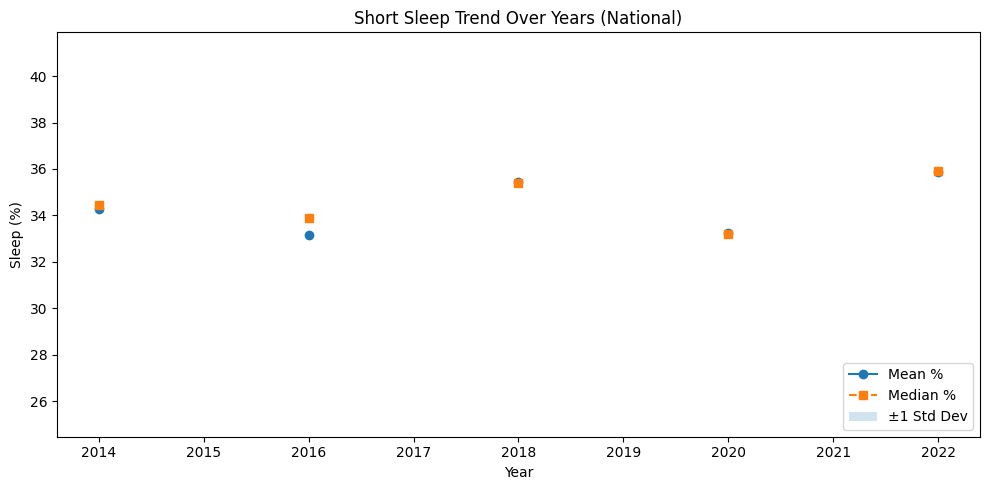

In [85]:
import matplotlib.pyplot as plt

yearly_sleep = df.groupby('year')['SLEEP'].agg(['mean', 'std', 'median']).round(2)
print(yearly_sleep)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_sleep.index, yearly_sleep['mean'], marker='o', label='Mean %')
ax.plot(yearly_sleep.index, yearly_sleep['median'], marker='s', linestyle='--', label='Median %')
ax.fill_between(yearly_sleep.index, 
                yearly_sleep['mean'] - yearly_sleep['std'], 
                yearly_sleep['mean'] + yearly_sleep['std'], 
                alpha=0.2, label='±1 Std Dev')

ax.set_title('Short Sleep Trend Over Years (National)')
ax.set_xlabel('Year')
ax.set_ylabel('Sleep (%)')
ax.legend()
plt.tight_layout()
plt.show()

## Stroke - central tendency and spread 

In [86]:
#STROKE country-wise

stroke_by_state = df.groupby('StateAbbr')['STROKE'].agg(
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).round(2)

stroke_by_state['IQR'] = stroke_by_state['q3'] - stroke_by_state['q1']

stroke_by_state.sort_values('mean', ascending=True)

,mean,median,std,min,max,q1,q3,IQR
StateAbbr,,,,,,,,
RI,2.71,2.70,0.12,2.50,3.00,2.65,2.75,0.10
CO,2.79,2.65,0.60,0.83,4.75,2.35,3.25,0.90
UT,2.84,2.88,0.49,0.89,3.65,2.60,3.19,0.59
NH,2.87,2.80,0.33,2.45,3.75,2.65,2.92,0.27
MA,2.94,2.88,0.50,2.03,4.21,2.61,3.15,0.54
VT,2.95,3.00,0.39,2.03,3.65,2.81,3.21,0.40
CT,2.96,2.85,0.37,2.40,3.77,2.75,3.03,0.28
ND,3.00,3.02,0.43,2.12,4.00,2.65,3.31,0.66
CA,3.01,2.96,0.60,0.85,6.26,2.69,3.40,0.71


## Outliers (State-wise)

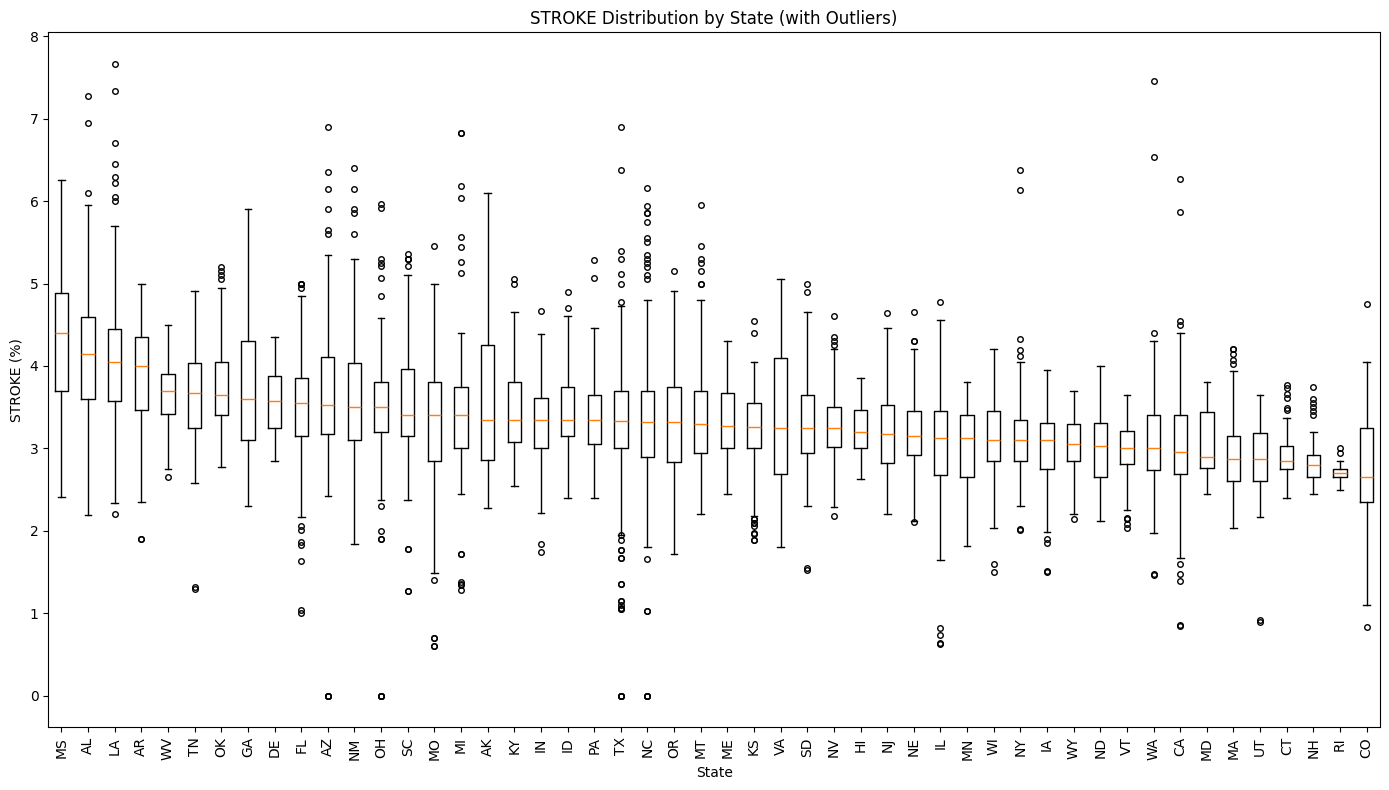

In [87]:
import matplotlib.pyplot as plt

stroke_data = df[['StateAbbr', 'STROKE']].dropna()

states_ordered = stroke_data.groupby('StateAbbr')['STROKE'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))

stroke_data_sorted = [stroke_data[stroke_data['StateAbbr'] == state]['STROKE'].values for state in states_ordered]

ax.boxplot(stroke_data_sorted, flierprops=dict(marker='o', color='red', markersize=4))

ax.set_xticks(range(1, len(states_ordered) + 1))
ax.set_xticklabels(states_ordered, rotation=90)
ax.set_title('STROKE Distribution by State (with Outliers)')
ax.set_xlabel('State')
ax.set_ylabel('STROKE (%)')
plt.tight_layout()
plt.show()

## Yearly Patterns - Stroke

      mean   std  median
year                    
2013   NaN   NaN     NaN
2014  2.99  0.85    2.96
2015  3.07  0.91    3.00
2016  3.05  1.34    2.80
2017  3.03  1.27    2.82
2018  3.48  0.62    3.45
2019  3.44  0.65    3.35
2020  3.23  0.60    3.15
2021  3.21  0.53    3.15
2022  3.58  0.67    3.50
2023  3.45  0.60    3.40


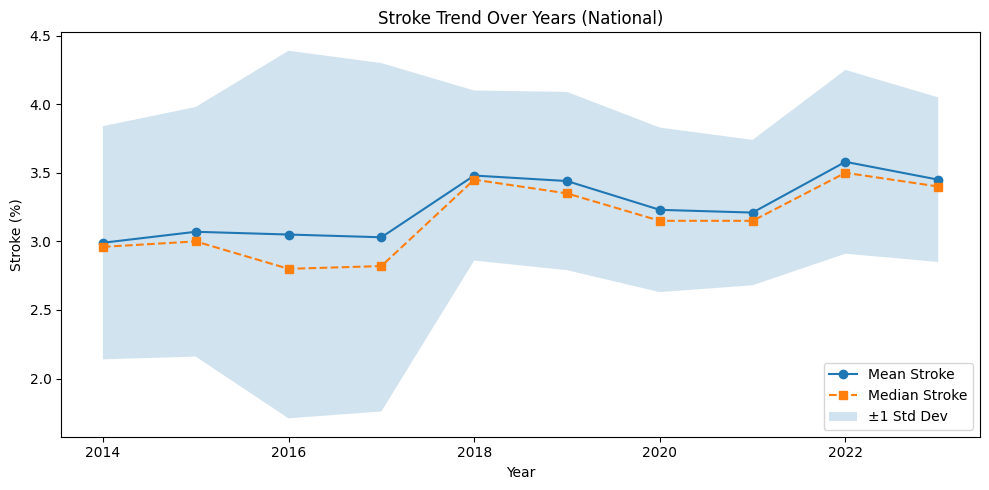

In [88]:
import matplotlib.pyplot as plt

yearly_stroke = df.groupby('year')['STROKE'].agg(['mean', 'std', 'median']).round(2)
print(yearly_stroke)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_stroke.index, yearly_stroke['mean'], marker='o', label='Mean Stroke')
ax.plot(yearly_stroke.index, yearly_stroke['median'], marker='s', linestyle='--', label='Median Stroke')
ax.fill_between(yearly_stroke.index, 
                yearly_stroke['mean'] - yearly_stroke['std'], 
                yearly_stroke['mean'] + yearly_stroke['std'], 
                alpha=0.2, label='±1 Std Dev')

ax.set_title('Stroke Trend Over Years (National)')
ax.set_xlabel('Year')
ax.set_ylabel('Stroke (%)')
ax.legend()
plt.tight_layout()
plt.show()

## Weather Variable Trends over Years

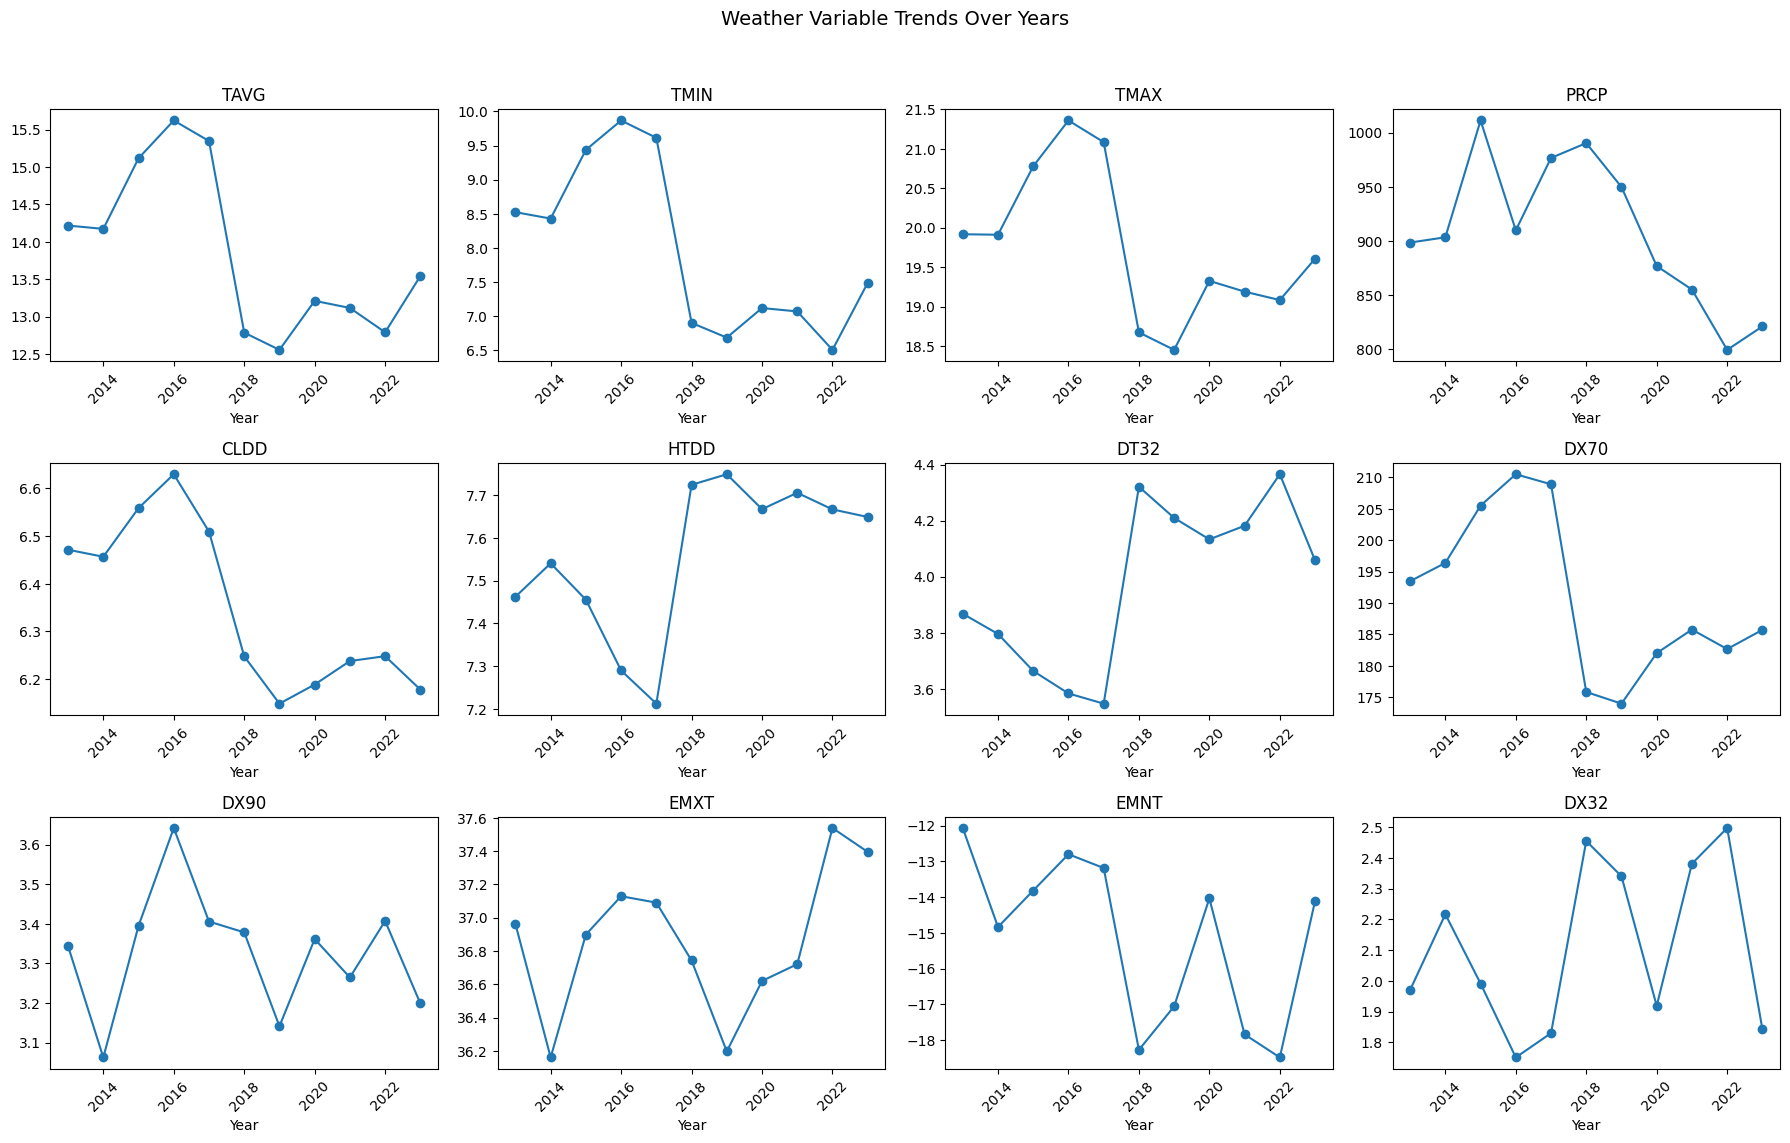

In [89]:
weather_cols = ['TAVG', 'TMIN', 'TMAX', 'PRCP', 'CLDD', 'HTDD', 
                 'DT32', 'DX70', 'DX90', 'EMXT', 'EMNT', 'DX32']

# See how much data each has
df[weather_cols].isnull().mean().mul(100).round(2).sort_values()

import matplotlib.pyplot as plt

weather_yearly = df.groupby('year')[weather_cols].mean()

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(weather_cols):
    axes[i].plot(weather_yearly.index, weather_yearly[col], marker='o')
    axes[i].set_title(col)
    axes[i].set_xlabel('Year')
    axes[i].tick_params(axis='x', rotation=45)

# hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Weather Variable Trends Over Years', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



In [90]:
# How many counties have weather data each year?
df.groupby('year')[['TAVG', 'PRCP', 'TMIN']].count()


,TAVG,PRCP,TMIN
year,,,
2013,246,252,246
2014,247,250,247
2015,251,251,251
2016,249,253,249
2017,246,252,246
2018,808,813,814
2019,820,810,824
2020,818,787,821
2021,828,796,831


In [91]:
# See which counties appear in 2014 but not 2016, and vice versa
counties_2014 = set(df[df['year'] == 2014].dropna(subset=['TAVG'])['County name'])
counties_2016 = set(df[df['year'] == 2016].dropna(subset=['TAVG'])['County name'])

print("In 2014 but not 2016:", counties_2014 - counties_2016)
print("In 2016 but not 2014:", counties_2016 - counties_2014)


In 2014 but not 2016: {'MIDDLESEX COUNTY', 'SONOMA COUNTY', 'PIERCE COUNTY', 'BRISTOL COUNTY'}
In 2016 but not 2014: {'ECTOR COUNTY', 'BOULDER COUNTY', 'KANE COUNTY', 'CRAIGHEAD COUNTY', 'MCLEAN COUNTY', 'FORSYTH COUNTY', 'SANDOVAL COUNTY'}


           avg_temp  mean_sleep
StateAbbr                      
HI            21.66       41.57
WV            12.47       40.46
AL            18.40       39.60
NJ            12.76       39.47
LA            20.74       39.26
GA            18.81       38.92
KY            14.43       38.73
MS            19.14       38.33
PA            11.45       38.09
OH            11.46       37.98
TN            15.81       37.62
NV            12.67       36.78
CT            11.46       36.75
DE            14.00       36.65
VA            15.59       36.63
AR            16.46       36.55
SC            18.22       36.54
OK            16.04       36.52
NY            10.00       36.49
FL            23.39       36.14
IN            11.98       35.93
TX            20.14       35.90
MD            14.40       35.71
MI             8.43       35.28
MA            10.50       35.24
MO            13.36       34.77
AK             1.53       34.72
IL            11.27       34.04
KS            13.50       33.58
NH      

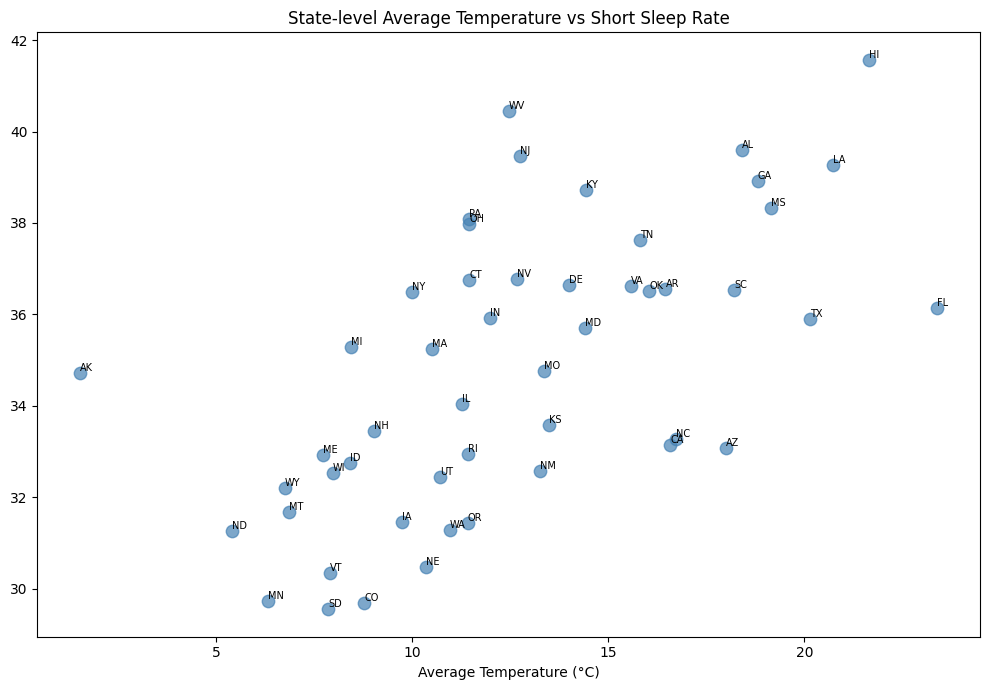

In [92]:
import matplotlib.pyplot as plt

# Aggregate to state level
state_temp_sleep = df.groupby('StateAbbr').agg(
    avg_temp=('TAVG', 'mean'),
    mean_sleep=('SLEEP', 'mean')
).dropna().round(2)

print(state_temp_sleep.sort_values('mean_sleep', ascending=False))

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(state_temp_sleep['avg_temp'], state_temp_sleep['mean_sleep'], 
           color='steelblue', s=80, alpha=0.7)

# Label each dot with state name
for state, row in state_temp_sleep.iterrows():
    ax.annotate(state, (row['avg_temp'], row['mean_sleep']), 
                fontsize=7, ha='left', va='bottom')

ax.set_xlabel('Average Temperature (°C)')
ax.set_title('State-level Average Temperature vs Short Sleep Rate')
plt.tight_layout()
plt.show()


In [93]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn'])


CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

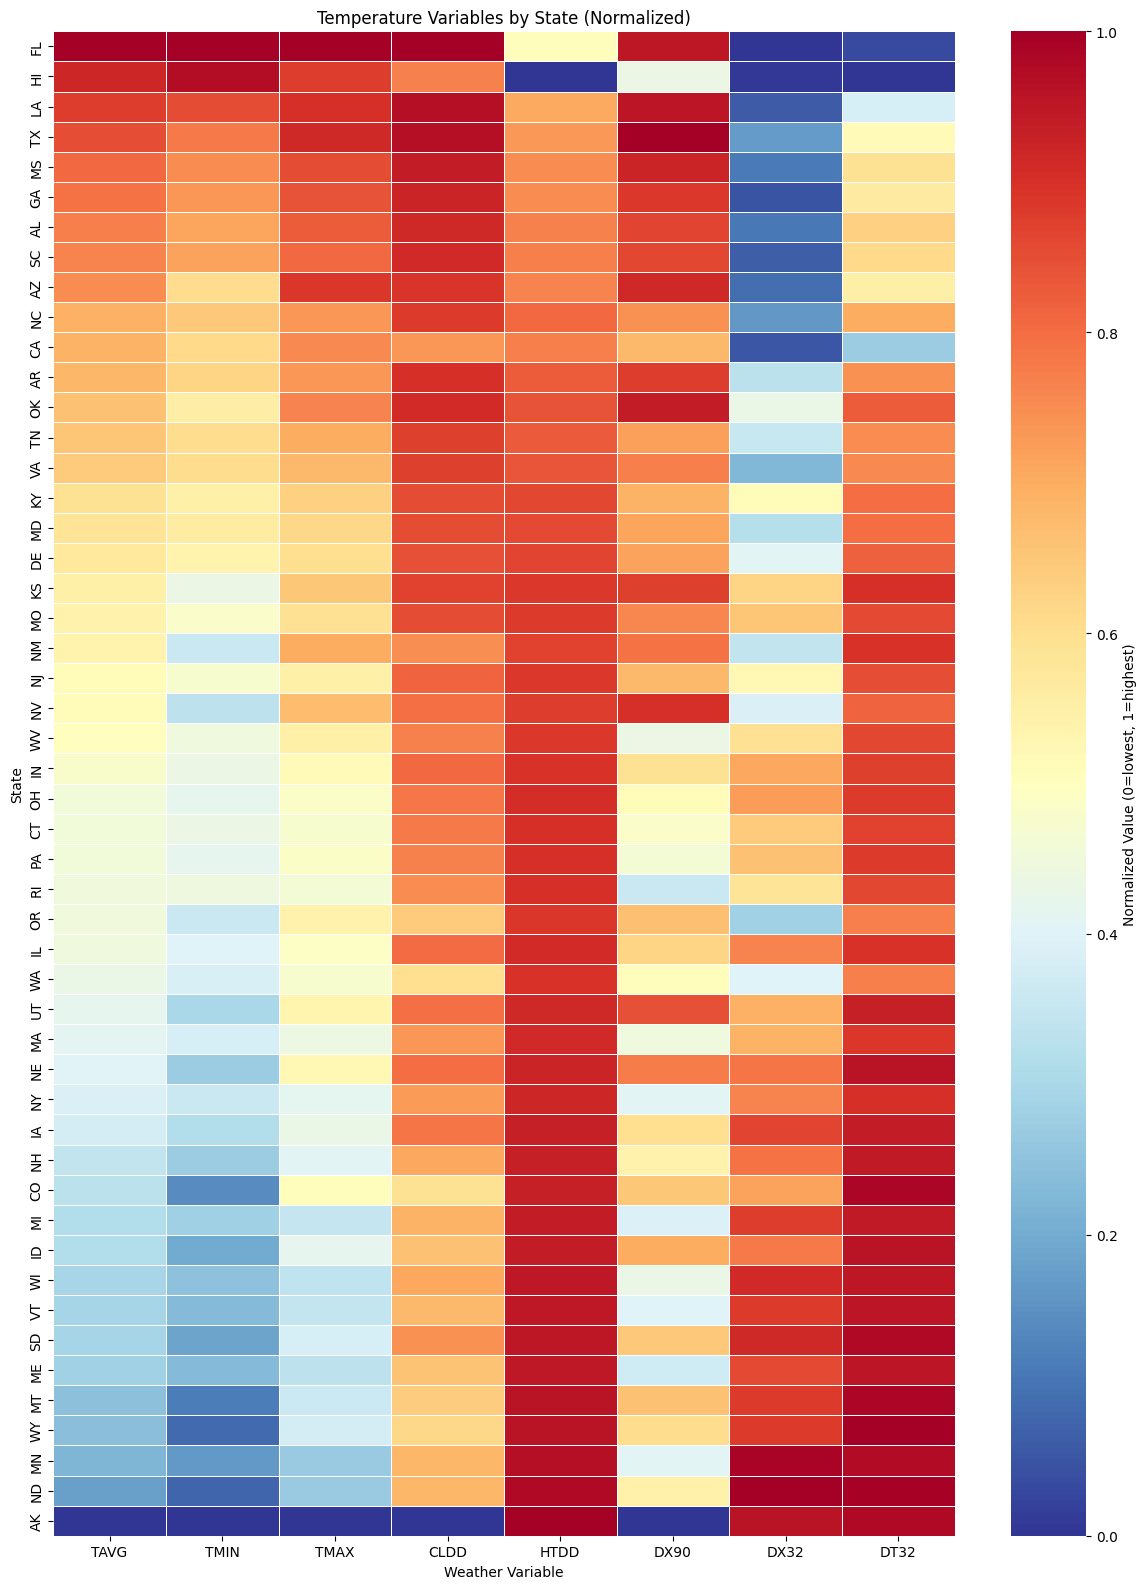

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

temp_cols = ['TAVG', 'TMIN', 'TMAX', 'CLDD', 'HTDD', 'DX90', 'DX32', 'DT32']

state_temp = df.groupby('StateAbbr')[temp_cols].mean().round(2)

# Normalize each column (0-1) so different units are comparable
state_temp_norm = (state_temp - state_temp.min()) / (state_temp.max() - state_temp.min())
state_temp_norm = state_temp_norm.sort_values('TAVG', ascending=False)

plt.figure(figsize=(12, 16))
sns.heatmap(state_temp_norm, 
            cmap='RdYlBu_r',
            annot=False,
            linewidths=0.5,
            cbar_kws={'label': 'Normalized Value (0=lowest, 1=highest)'})

plt.title('Temperature Variables by State (Normalized)')
plt.xlabel('Weather Variable')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('../EDA/temp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Temperature Outliers

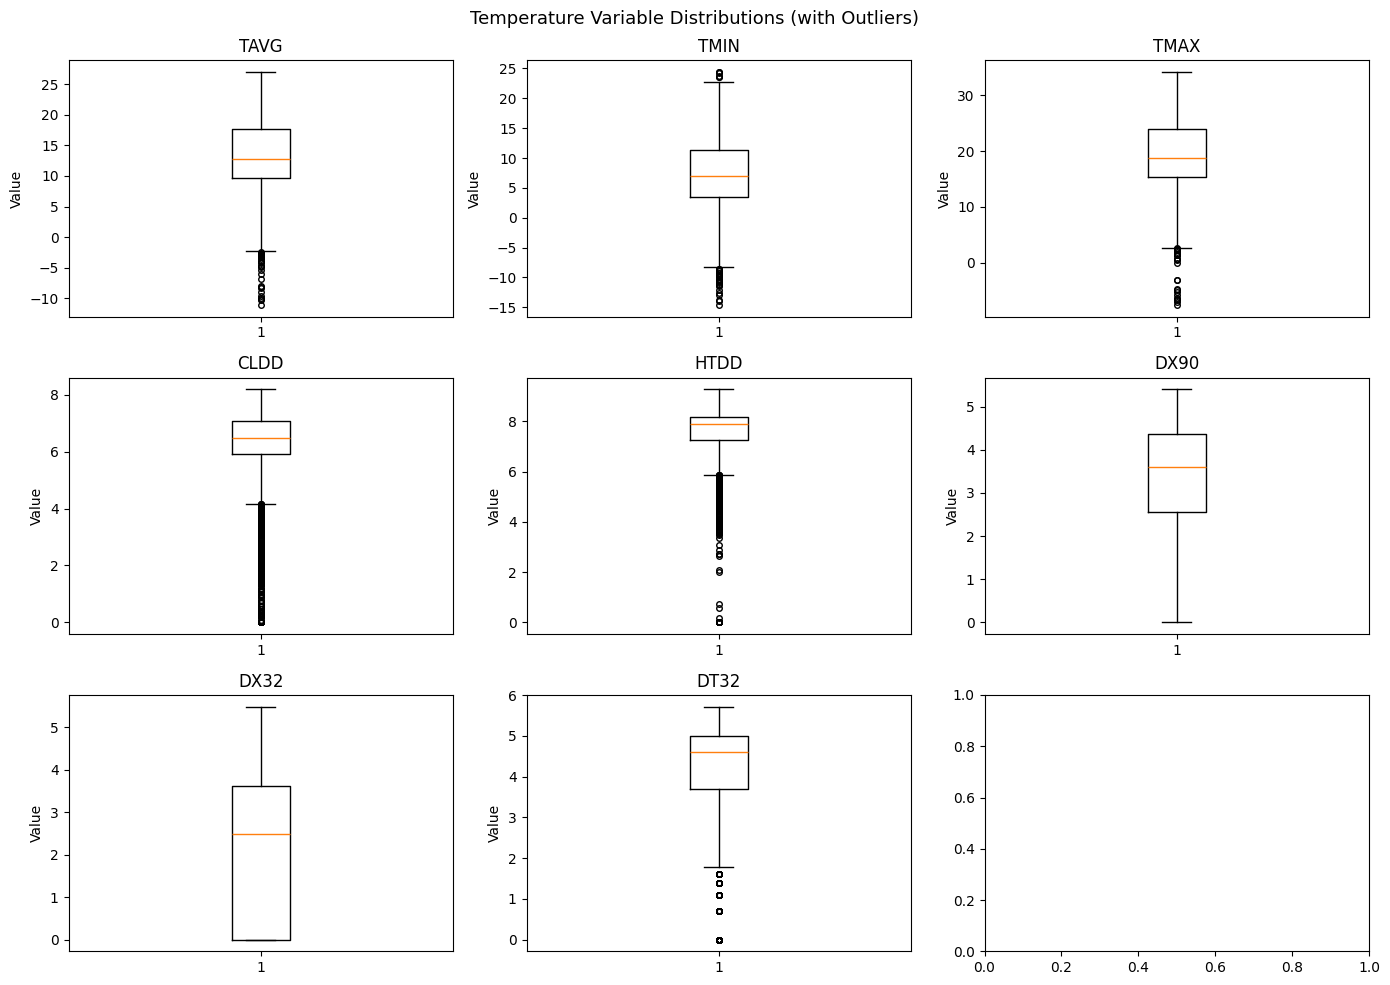

In [95]:

import matplotlib.pyplot as plt

temp_cols = ['TAVG', 'TMIN', 'TMAX', 'CLDD', 'HTDD', 'DX90', 'DX32', 'DT32']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(temp_cols):
    axes[i].boxplot(df[col].dropna(), 
                    flierprops=dict(marker='o', color='red', markersize=4))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Temperature Variable Distributions (with Outliers)', fontsize=13)
plt.tight_layout()
plt.show()


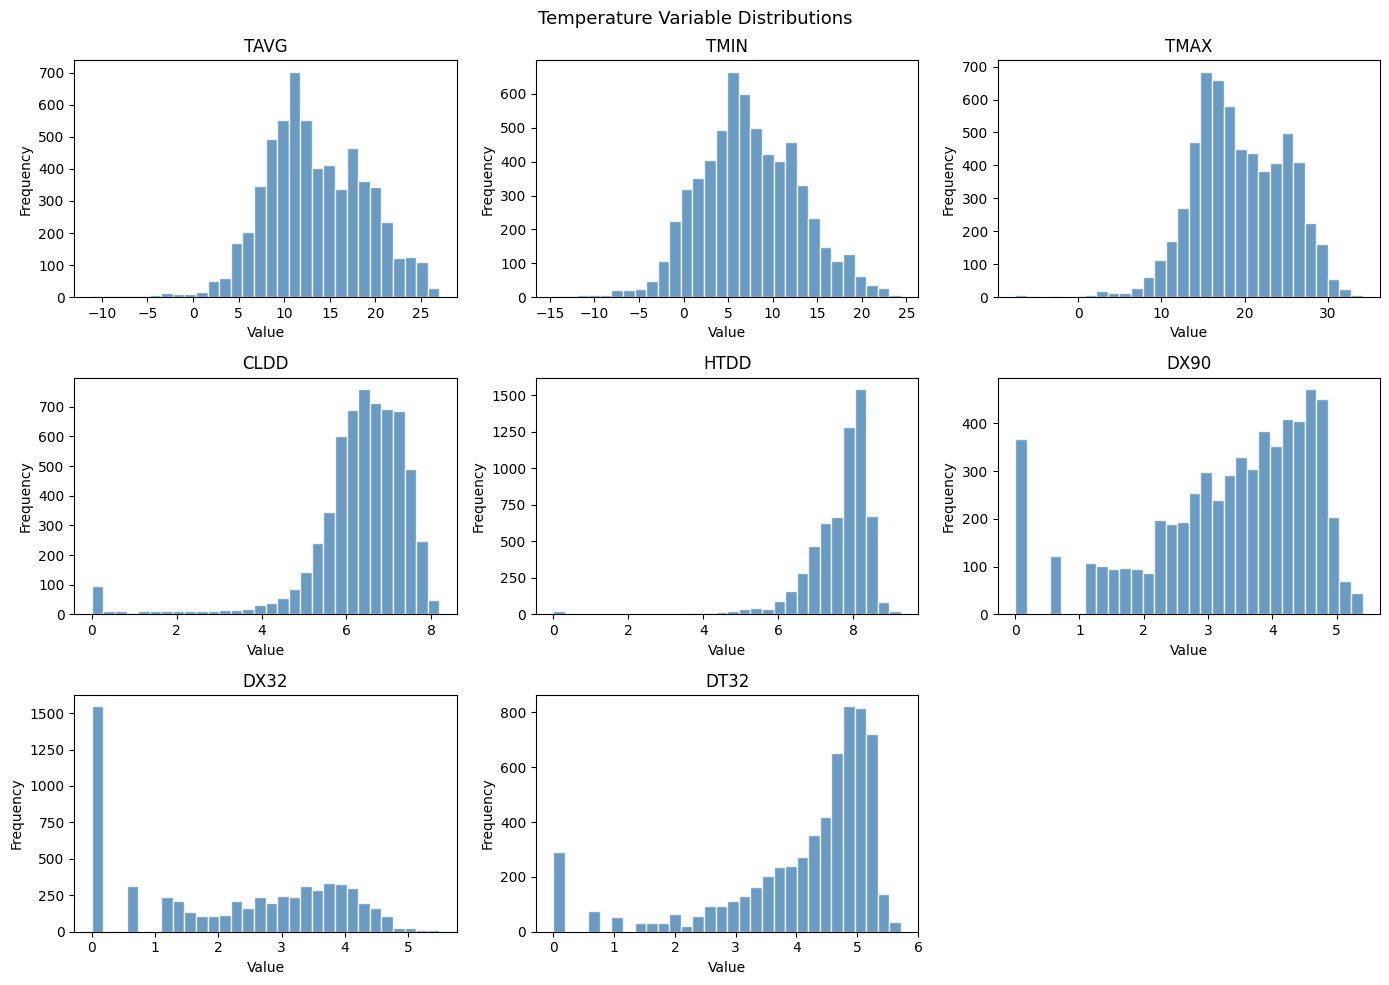

In [96]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(temp_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlabel('Value')

# Hide the last unused subplot (9 subplots, 8 variables)
axes[-1].set_visible(False)

plt.suptitle('Temperature Variable Distributions', fontsize=13)
plt.tight_layout()
plt.show()

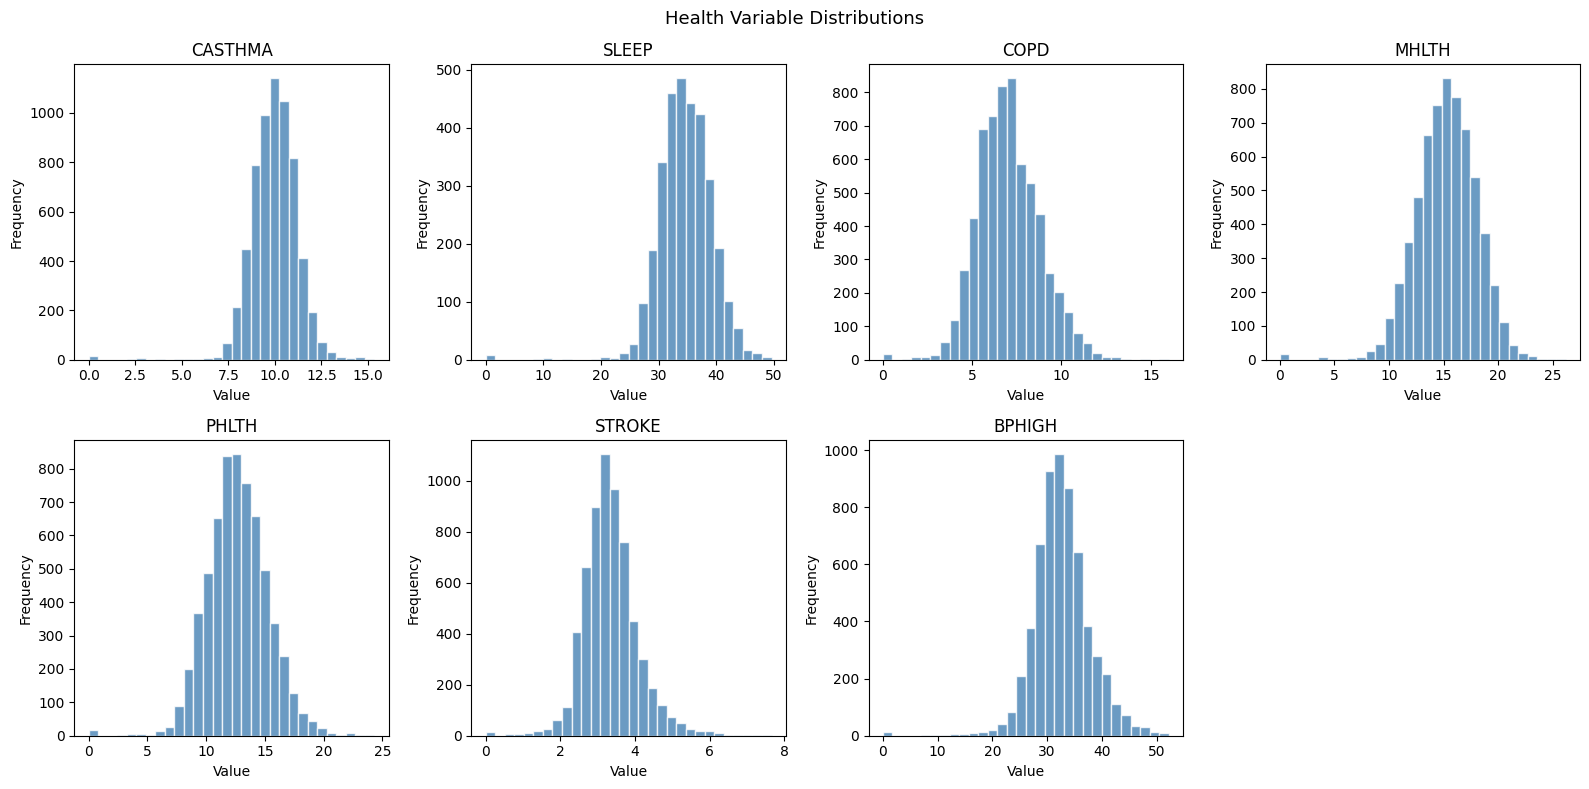

In [97]:
health_vars = ['CASTHMA', 'SLEEP', 'COPD', 
               'MHLTH', 'PHLTH', 'STROKE', 'BPHIGH']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(health_vars):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlabel('Value')

# Hide only the last unused subplot (8 subplots, 7 variables)
axes[-1].set_visible(False)

plt.suptitle('Health Variable Distributions', fontsize=13)
plt.tight_layout()
plt.show()

All health variables appear normally distributed though the several of the temperature variables are skewed so may benefit from log transformations